In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nidhin17/retail-sales/retail_sales.csv


In [3]:
import pandas as pd
import numpy as np

# ==============================
# 1. LOAD DATASET
# ==============================
df = pd.read_csv("/kaggle/input/datasets/nidhin17/retail-sales/retail_sales.csv")
print("Dataset Loaded Successfully!\n")

# ==============================
# 2. BASIC STRUCTURE
# ==============================
print("Shape of dataset:", df.shape)
print("\nColumn names:\n", df.columns.tolist())

print("\nFirst 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())

# ==============================
# 3. DATA TYPES & INFO
# ==============================
print("\nData Types:\n", df.dtypes)

print("\nDataset Info:")
df.info()

# ==============================
# 4. MISSING VALUES
# ==============================
print("\nMissing Values Count:\n", df.isnull().sum())

print("\nMissing Values Percentage:\n",
      (df.isnull().sum() / len(df)) * 100)

# ==============================
# 5. DUPLICATE VALUES
# ==============================
print("\nNumber of Duplicate Rows:", df.duplicated().sum())

# ==============================
# 6. STATISTICAL SUMMARY
# ==============================
print("\nNumerical Summary:\n", df.describe())

print("\nFull Summary (Including Categorical):\n",
      df.describe(include='all'))

# ==============================
# 7. UNIQUE VALUES
# ==============================
print("\nUnique Values Per Column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# ==============================
# 8. VALUE COUNTS (CATEGORICAL)
# ==============================
print("\nCategorical Value Counts:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())

# ==============================
# 9. CORRELATION ANALYSIS
# ==============================
print("\nCorrelation Matrix:\n",
      df.corr(numeric_only=True))

# ==============================
# 10. OUTLIER DETECTION (IQR)
# ==============================
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Compute IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((numeric_df < (Q1 - 1.5 * IQR)) |
            (numeric_df > (Q3 + 1.5 * IQR)))

print("\nOutliers Count Per Column:\n", outliers.sum())
           

# ==============================
# 11. BASIC FILTERING EXAMPLES
# ==============================
print("\nSample Filtering (first column > mean):")
num_cols = df.select_dtypes(include=np.number).columns

if len(num_cols) > 0:
    col = num_cols[0]
    print(df[df[col] > df[col].mean()].head())

# ==============================
# 12. GROUPBY EXAMPLE
# ==============================
print("\nGroupBy Example (if categorical exists):")
cat_cols = df.select_dtypes(include=['object']).columns

if len(cat_cols) > 0 and len(num_cols) > 0:
    print(df.groupby(cat_cols[0])[num_cols[0]].mean())

# ==============================
# 13. SORTING
# ==============================
if len(num_cols) > 0:
    print("\nTop 5 values sorted by", num_cols[0])
    print(df.sort_values(by=num_cols[0], ascending=False).head())

# ==============================
# 14. SAMPLE DATA
# ==============================
print("\nRandom Sample:\n", df.sample(5))



Dataset Loaded Successfully!

Shape of dataset: (1048575, 8)

Column names:
 ['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday', 'month']

First 5 rows:
          date store_id item_id  sales  price  promo  weekday  month
0  01-01-2019  store_1  item_1     41  21.30      0        1      1
1  02-01-2019  store_1  item_1     53  21.30      0        2      1
2  03-01-2019  store_1  item_1     39  21.30      0        3      1
3  04-01-2019  store_1  item_1     35  21.30      0        4      1
4  05-01-2019  store_1  item_1     51  17.04      1        5      1

Last 5 rows:
                date  store_id  item_id  sales  price  promo  weekday  month
1048570  22-03-2020  store_12  item_25     42  41.85      0        6      3
1048571  23-03-2020  store_12  item_25     56  41.85      0        0      3
1048572  24-03-2020  store_12  item_25     59  41.85      0        1      3
1048573  25-03-2020  store_12  item_25     55  41.85      0        2      3
1048574  26-03-2020  stor

Data Loaded!
Feature Engineering Done!
Train/Test Split Done!
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076011 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2037
[LightGBM] [Info] Number of data points in the train set: 804565, number of used features: 18
[LightGBM] [Info] Start training from score 29.068587
Model Training Completed!

Model Performance:
MAE: 2.6187959186546736
RMSE: 3.288924793106571


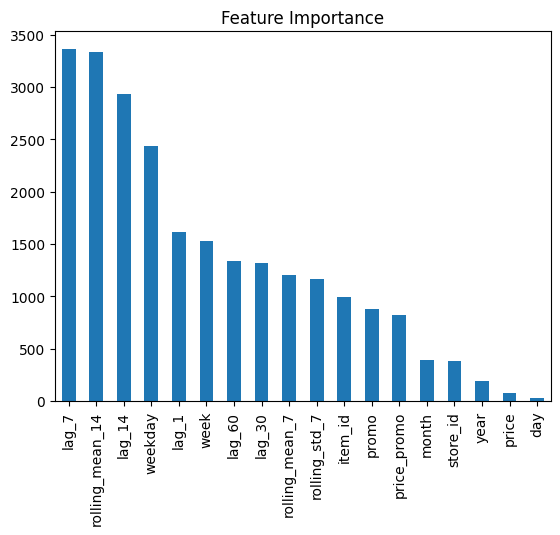

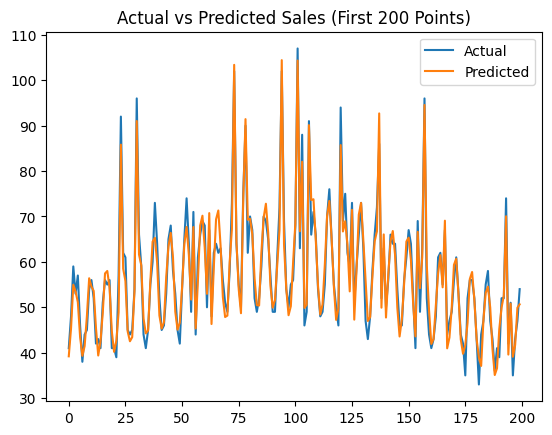

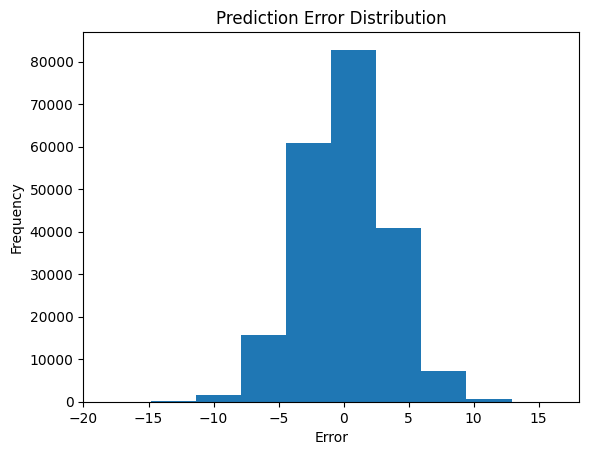

SMAPE: 10.274520729064314

Pipeline Completed Successfully!


In [8]:
# ==============================
# 1. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv("/kaggle/input/datasets/nidhin17/retail-sales/retail_sales.csv")

# Convert date
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

# Sort data
df = df.sort_values(['store_id', 'item_id', 'date'])

print("Data Loaded!")

# ==============================
# 3. FEATURE ENGINEERING
# ==============================

# Time features
df['day'] = df['date'].dt.day
df['week'] = df['date'].dt.isocalendar().week.astype(int)
df['year'] = df['date'].dt.year

# Lag features
df['lag_1'] = df.groupby(['store_id', 'item_id'])['sales'].shift(1)
df['lag_7'] = df.groupby(['store_id', 'item_id'])['sales'].shift(7)
df['lag_30'] = df.groupby(['store_id', 'item_id'])['sales'].shift(30)
df['lag_14'] = df.groupby(['store_id', 'item_id'])['sales'].shift(14)
df['lag_60'] = df.groupby(['store_id', 'item_id'])['sales'].shift(60)

# NEW ROLLING FEATURE
df['rolling_mean_14'] = df.groupby(['store_id', 'item_id'])['sales'].shift(1).rolling(14).mean()
df['rolling_mean_7'] = df.groupby(['store_id', 'item_id'])['sales'].shift(1).rolling(7).mean()
df['rolling_std_7'] = df.groupby(['store_id', 'item_id'])['sales'].shift(1).rolling(7).std()

# Encode categorical
df['store_id'] = df['store_id'].astype('category').cat.codes
df['item_id'] = df['item_id'].astype('category').cat.codes

# INTERACTION FEATURE
df['price_promo'] = df['price'] * df['promo']

# Drop NaN rows
df = df.dropna()

print("Feature Engineering Done!")

# ==============================
# 4. TRAIN-TEST SPLIT (TIME BASED)
# ==============================
train = df[df['date'] < '2023-01-01']
test  = df[df['date'] >= '2023-01-01']

# Features & target
features = [
    'store_id', 'item_id',
    'price', 'promo', 'price_promo',
    'weekday', 'month',
    'day', 'week', 'year',
    'lag_1', 'lag_7', 'lag_14', 'lag_30', 'lag_60',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7'
]

target = 'sales'

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train/Test Split Done!")

# ==============================
# 5. MODEL TRAINING (LightGBM)
# ==============================
model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model Training Completed!")

# ==============================
# 6. PREDICTIONS
# ==============================
preds = model.predict(X_test)

# ==============================
# 7. EVALUATION
# ==============================
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print("\nModel Performance:")
print("MAE:", mae)
print("RMSE:", rmse)

# ==============================
# 8. FEATURE IMPORTANCE
# ==============================
importance = pd.Series(model.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

plt.figure()
importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

# ==============================
# 9. ACTUAL vs PREDICTED
# ==============================
plt.figure()
plt.plot(y_test.values[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Sales (First 200 Points)")
plt.show()

# ==============================
# 10. ERROR DISTRIBUTION
# ==============================
errors = y_test - preds

plt.figure()
plt.hist(errors)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

# ==============================
# 11. Symmetric Mean Absolute Percentage Error
# ==============================
smape = np.mean(
    2 * np.abs(y_test - preds) / (np.abs(y_test) + np.abs(preds))
) * 100

print("SMAPE:", smape)

# ==============================
# 12. SAVE MODEL
# ==============================
import joblib
joblib.dump(model, "demand_forecast_lgbm.pkl")

print("\nPipeline Completed Successfully!")





In [10]:
import joblib
joblib.dump(model, "/kaggle/working/demand_forecast_lgbm.pkl")
joblib.dump(model, "demand_forecast_lgbm.pkl")

['demand_forecast_lgbm.pkl']